In [31]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from fluent_fno_pipeline import build_fluent_fno_dataset
from fno_model_flexible import FNO2d, UnitGaussianNormalizer

In [32]:
ROOT_DIR = Path("/home/hantianl/Documents/PIDIF/runs_2d/rect_ar")

train_ars = list(range(10, 31))

case_files = {
    i: {
        "mesh": ROOT_DIR / f"rect_ar{i:02d}_1e-1mps_2c/rect_ar{i:02d}.msh.h5",
        "dat": ROOT_DIR / f"rect_ar{i:02d}_1e-1mps_2c/case2d.dat.h5",
    }
    for i in train_ars
}

In [33]:
nx = 256
ny = 256
n_subdomains = 10

INPUT_MODE = "local_full16_broadcast"
# INPUT_MODE = "local_left12_broadcast"

dataset = build_fluent_fno_dataset(
    case_files=case_files,
    ar_min=10,
    ar_max=30,
    nx=nx,
    ny=ny,
    n_subdomains=n_subdomains,
    input_mode=INPUT_MODE,
    layout="NHWC",
)

X = dataset["inputs"].astype(np.float32)
Y = dataset["outputs"].astype(np.float32)

input_channel_names = list(dataset["input_channel_names"])
output_channel_names = list(dataset["output_channel_names"])

ars = np.asarray(dataset["aspect_ratio"]).astype(int)
subdomain_ids = np.asarray(dataset["subdomain_id"]).astype(int)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Input channels:", input_channel_names)
print("Output channels:", output_channel_names)
print("ARs:", sorted(set(ars.tolist())))
print("Subdomains:", sorted(set(subdomain_ids.tolist())))

Processing AR=10
Processing AR=11
Processing AR=12
Processing AR=13
Processing AR=14
Processing AR=15
Processing AR=16
Processing AR=17
Processing AR=18
Processing AR=19
Processing AR=20
Processing AR=21
Processing AR=22
Processing AR=23
Processing AR=24
Processing AR=25
Processing AR=26
Processing AR=27
Processing AR=28
Processing AR=29
Processing AR=30
X shape: (210, 256, 256, 16)
Y shape: (210, 256, 256, 4)
Input channels: ['fluid_mask', 'left_interface_mask', 'right_interface_mask', 'wall_mask', 'local_aspect_ratio', 'left_pressure', 'left_temperature', 'left_u', 'left_v', 'right_pressure', 'right_temperature', 'right_u', 'right_v', 'wall_temperature', 'wall_u', 'wall_v']
Output channels: ['pressure', 'temperature', 'u', 'v']
ARs: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Subdomains: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [34]:
valid_ars = [20, 25, 30]

valid_mask = np.isin(ars, valid_ars)
train_mask = ~valid_mask

train_idx = np.flatnonzero(train_mask)
valid_idx = np.flatnonzero(valid_mask)

print("Train samples:", len(train_idx))
print("Valid samples:", len(valid_idx))
print("Train ARs:", sorted(set(ars[train_idx].tolist())))
print("Valid ARs:", sorted(set(ars[valid_idx].tolist())))

Train samples: 180
Valid samples: 30
Train ARs: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 26, 27, 28, 29]
Valid ARs: [20, 25, 30]


In [35]:
X_train_raw = torch.from_numpy(X[train_idx]).float()
Y_train_raw = torch.from_numpy(Y[train_idx]).float()

X_valid_raw = torch.from_numpy(X[valid_idx]).float()
Y_valid_raw = torch.from_numpy(Y[valid_idx]).float()

x_normalizer = UnitGaussianNormalizer(X_train_raw)
y_normalizer = UnitGaussianNormalizer(Y_train_raw)

X_train = x_normalizer.encode(X_train_raw)
Y_train = y_normalizer.encode(Y_train_raw)

X_valid = x_normalizer.encode(X_valid_raw)
Y_valid = y_normalizer.encode(Y_valid_raw)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_valid:", X_valid.shape)
print("Y_valid:", Y_valid.shape)

X_train: torch.Size([180, 256, 256, 16])
Y_train: torch.Size([180, 256, 256, 4])
X_valid: torch.Size([30, 256, 256, 16])
Y_valid: torch.Size([30, 256, 256, 4])


In [36]:
BATCH_SIZE = 20

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

valid_loader = DataLoader(
    TensorDataset(X_valid, Y_valid),
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

In [37]:
def relative_l2_batch(pred, truth, eps=1.0e-12):
    pred_flat = pred.reshape(pred.shape[0], -1)
    truth_flat = truth.reshape(truth.shape[0], -1)

    numerator = torch.linalg.norm(pred_flat - truth_flat, dim=1)
    denominator = torch.linalg.norm(truth_flat, dim=1).clamp_min(eps)

    return (numerator / denominator).mean()


@torch.no_grad()
def evaluate_model(model, loader, y_normalizer, device):
    model.eval()

    mse_sum = 0.0
    rel_sum = 0.0
    n_total = 0

    n_fields = len(output_channel_names)
    channel_sse = torch.zeros(n_fields, device=device)
    channel_energy = torch.zeros(n_fields, device=device)

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred_norm = model(xb)
        mse = F.mse_loss(pred_norm, yb, reduction="mean")

        pred_phys = y_normalizer.decode(pred_norm)
        truth_phys = y_normalizer.decode(yb)

        batch_size = xb.shape[0]
        mse_sum += float(mse.item()) * batch_size
        rel_sum += float(relative_l2_batch(pred_phys, truth_phys).item()) * batch_size
        n_total += batch_size

        diff = pred_phys - truth_phys
        channel_sse += torch.sum(diff ** 2, dim=(0, 1, 2))
        channel_energy += torch.sum(truth_phys ** 2, dim=(0, 1, 2))

    mse_avg = mse_sum / max(n_total, 1)
    rel_avg = rel_sum / max(n_total, 1)
    channel_rel_l2 = torch.sqrt(channel_sse / channel_energy.clamp_min(1.0e-12))

    return mse_avg, rel_avg, channel_rel_l2.detach().cpu().numpy()

In [38]:
torch.manual_seed(0)
np.random.seed(0)

DEVICE = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

EPOCHS = 2000
LEARNING_RATE = 1.0e-3
WEIGHT_DECAY = 1.0e-4

MODES1 = 16
MODES2 = 16
WIDTH = 32
PADDING = 9

model = FNO2d(
    input_channels=X_train.shape[-1],
    output_channels=Y_train.shape[-1],
    modes1=MODES1,
    modes2=MODES2,
    width=WIDTH,
    padding=PADDING,
    append_grid=True,
).to(DEVICE)

x_normalizer = x_normalizer.to(DEVICE)
y_normalizer = y_normalizer.to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)

checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = checkpoint_dir / f"fno_rect_ar{ars.min():02d}_{ars.max():02d}_{INPUT_MODE}.pt"

best_valid_rel = float("inf")
history = []

# Per-iteration (epoch) trackers for plotting later.
epoch_list = []
train_loss_per_iter = []
valid_loss_per_iter = []
valid_rel_l2_per_iter = []

for epoch in range(1, EPOCHS + 1):
    model.train()

    train_mse_sum = 0.0
    n_train = 0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        pred = model(xb)
        loss = F.mse_loss(pred, yb)

        loss.backward()
        optimizer.step()

        batch_size = xb.shape[0]
        train_mse_sum += float(loss.item()) * batch_size
        n_train += batch_size

    scheduler.step()

    train_mse = train_mse_sum / max(n_train, 1)

    valid_mse, valid_rel_l2, valid_channel_rel_l2 = evaluate_model(
        model,
        valid_loader,
        y_normalizer,
        DEVICE,
    )

    epoch_list.append(epoch)
    train_loss_per_iter.append(float(train_mse))
    valid_loss_per_iter.append(float(valid_mse))
    valid_rel_l2_per_iter.append(float(valid_rel_l2))

    history.append(
        {
            "epoch": epoch,
            "train_mse_norm": train_mse,
            "valid_mse_norm": valid_mse,
            "valid_rel_l2_phys": valid_rel_l2,
            "valid_channel_rel_l2": valid_channel_rel_l2,
        }
    )

    if valid_rel_l2 < best_valid_rel:
        best_valid_rel = valid_rel_l2

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "model_config": model.config(),
                "x_normalizer": x_normalizer.state_dict(),
                "y_normalizer": y_normalizer.state_dict(),
                "input_channel_names": input_channel_names,
                "output_channel_names": output_channel_names,
                "input_mode": INPUT_MODE,
                "train_ars": sorted(set(ars[train_idx].tolist())),
                "valid_ars": sorted(set(ars[valid_idx].tolist())),
                "nx": nx,
                "ny": ny,
                "n_subdomains": n_subdomains,
            },
            checkpoint_path,
        )

    if epoch == 1 or epoch % 10 == 0:
        channel_msg = ", ".join(
            f"{name}={err:.3e}"
            for name, err in zip(output_channel_names, valid_channel_rel_l2)
        )

        print(
            f"Epoch {epoch:04d} | "
            f"train MSE(norm)={train_mse:.3e} | "
            f"valid MSE(norm)={valid_mse:.3e} | "
            f"valid rel L2(phys)={valid_rel_l2:.3e} | "
            f"{channel_msg}"
        )

# Save iteration-wise loss history for reuse.
loss_history_path = checkpoint_dir / f"loss_history_rect_ar{ars.min():02d}_{ars.max():02d}_{INPUT_MODE}.npz"
np.savez(
    loss_history_path,
    epoch=np.asarray(epoch_list, dtype=np.int32),
    train_mse_norm=np.asarray(train_loss_per_iter, dtype=np.float32),
    valid_mse_norm=np.asarray(valid_loss_per_iter, dtype=np.float32),
    valid_rel_l2_phys=np.asarray(valid_rel_l2_per_iter, dtype=np.float32),
)

print("Best validation relative L2:", best_valid_rel)
print("Saved best checkpoint to:", checkpoint_path)
print("Saved loss history to:", loss_history_path)


Device: cuda:3
Epoch 0001 | train MSE(norm)=9.815e-01 | valid MSE(norm)=1.020e+00 | valid rel L2(phys)=1.911e-03 | pressure=5.804e-01, temperature=1.921e-03, u=3.374e-01, v=9.938e-01
Epoch 0010 | train MSE(norm)=1.367e-02 | valid MSE(norm)=1.088e-02 | valid rel L2(phys)=2.016e-04 | pressure=3.779e-02, temperature=2.139e-04, u=3.467e-02, v=1.425e-01
Epoch 0020 | train MSE(norm)=2.038e-03 | valid MSE(norm)=2.145e-03 | valid rel L2(phys)=9.316e-05 | pressure=1.500e-02, temperature=9.971e-05, u=1.296e-02, v=6.954e-02
Epoch 0030 | train MSE(norm)=1.012e-03 | valid MSE(norm)=1.007e-03 | valid rel L2(phys)=5.731e-05 | pressure=1.049e-02, temperature=5.991e-05, u=8.806e-03, v=5.201e-02
Epoch 0040 | train MSE(norm)=6.893e-04 | valid MSE(norm)=7.106e-04 | valid rel L2(phys)=4.378e-05 | pressure=8.240e-03, temperature=4.625e-05, u=7.145e-03, v=4.664e-02
Epoch 0050 | train MSE(norm)=5.740e-04 | valid MSE(norm)=5.451e-04 | valid rel L2(phys)=3.634e-05 | pressure=6.813e-03, temperature=3.852e-05, u=

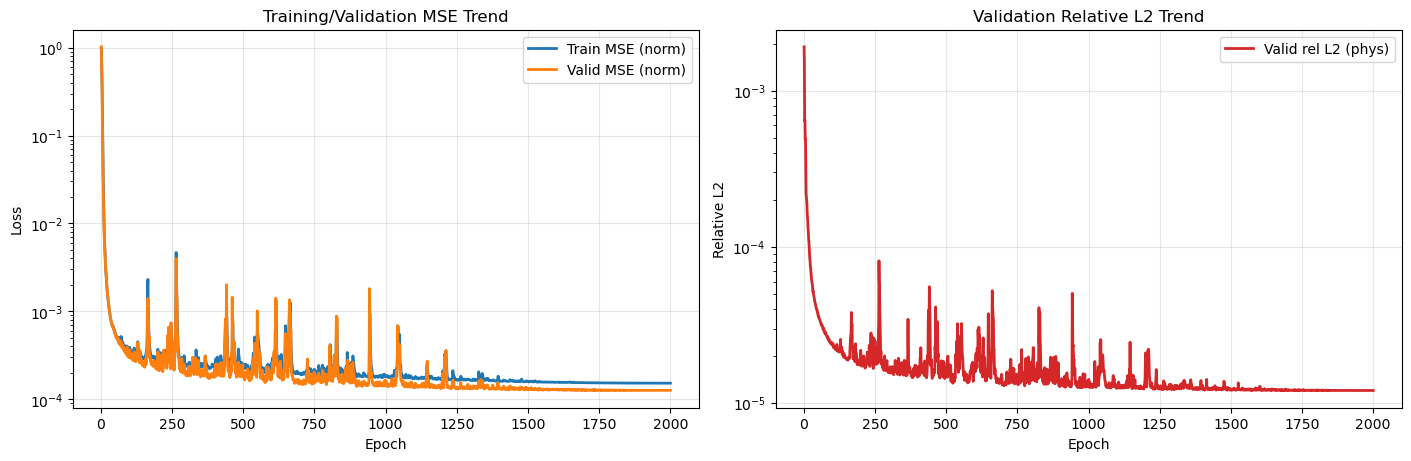

In [39]:
# Plot training/validation loss trend over iterations (epochs)
epochs = np.asarray(epoch_list)
train_loss_arr = np.asarray(train_loss_per_iter)
valid_loss_arr = np.asarray(valid_loss_per_iter)
valid_rel_l2_arr = np.asarray(valid_rel_l2_per_iter)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].plot(epochs, train_loss_arr, label="Train MSE (norm)", linewidth=2)
axes[0].plot(epochs, valid_loss_arr, label="Valid MSE (norm)", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training/Validation MSE Trend")
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")
axes[0].legend()

axes[1].plot(epochs, valid_rel_l2_arr, color="tab:red", label="Valid rel L2 (phys)", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Relative L2")
axes[1].set_title("Validation Relative L2 Trend")
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale("log")
axes[1].legend()

plt.show()

In [40]:
ckpt = torch.load(checkpoint_path, map_location=DEVICE)

best_model = FNO2d(**ckpt["model_config"]).to(DEVICE)
best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()

x_normalizer = UnitGaussianNormalizer.from_state_dict(ckpt["x_normalizer"]).to(DEVICE)
y_normalizer = UnitGaussianNormalizer.from_state_dict(ckpt["y_normalizer"]).to(DEVICE)

preds = []
truths = []

with torch.no_grad():
    for xb, yb in valid_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        pred_norm = best_model(xb)

        pred_phys = y_normalizer.decode(pred_norm)
        truth_phys = y_normalizer.decode(yb)

        preds.append(pred_phys.detach().cpu().numpy())
        truths.append(truth_phys.detach().cpu().numpy())

pred_valid = np.concatenate(preds, axis=0)
truth_valid = np.concatenate(truths, axis=0)

print("pred_valid:", pred_valid.shape)
print("truth_valid:", truth_valid.shape)

pred_valid: (30, 256, 256, 4)
truth_valid: (30, 256, 256, 4)


/tmp/ipykernel_973637/1299930204.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=DEVICE)


In [ ]:
pred_path = f"results/valid_predictions_ar{valid_ars[0]}_{INPUT_MODE}_{EPOCHS}e.npz"

np.savez(
    pred_path,
    pred=pred_valid,
    truth=truth_valid,
    valid_indices=valid_idx,
    valid_ars=ars[valid_idx],
    valid_subdomain_ids=subdomain_ids[valid_idx],
    input_channel_names=np.array(input_channel_names, dtype=object),
    output_channel_names=np.array(output_channel_names, dtype=object),
)

print("Saved:", pred_path)

Saved: results/valid_predictions_ar20_local_full16_broadcast.npz


Validation sample:
AR: 20
Subdomain: 0
Stitched subdomains: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


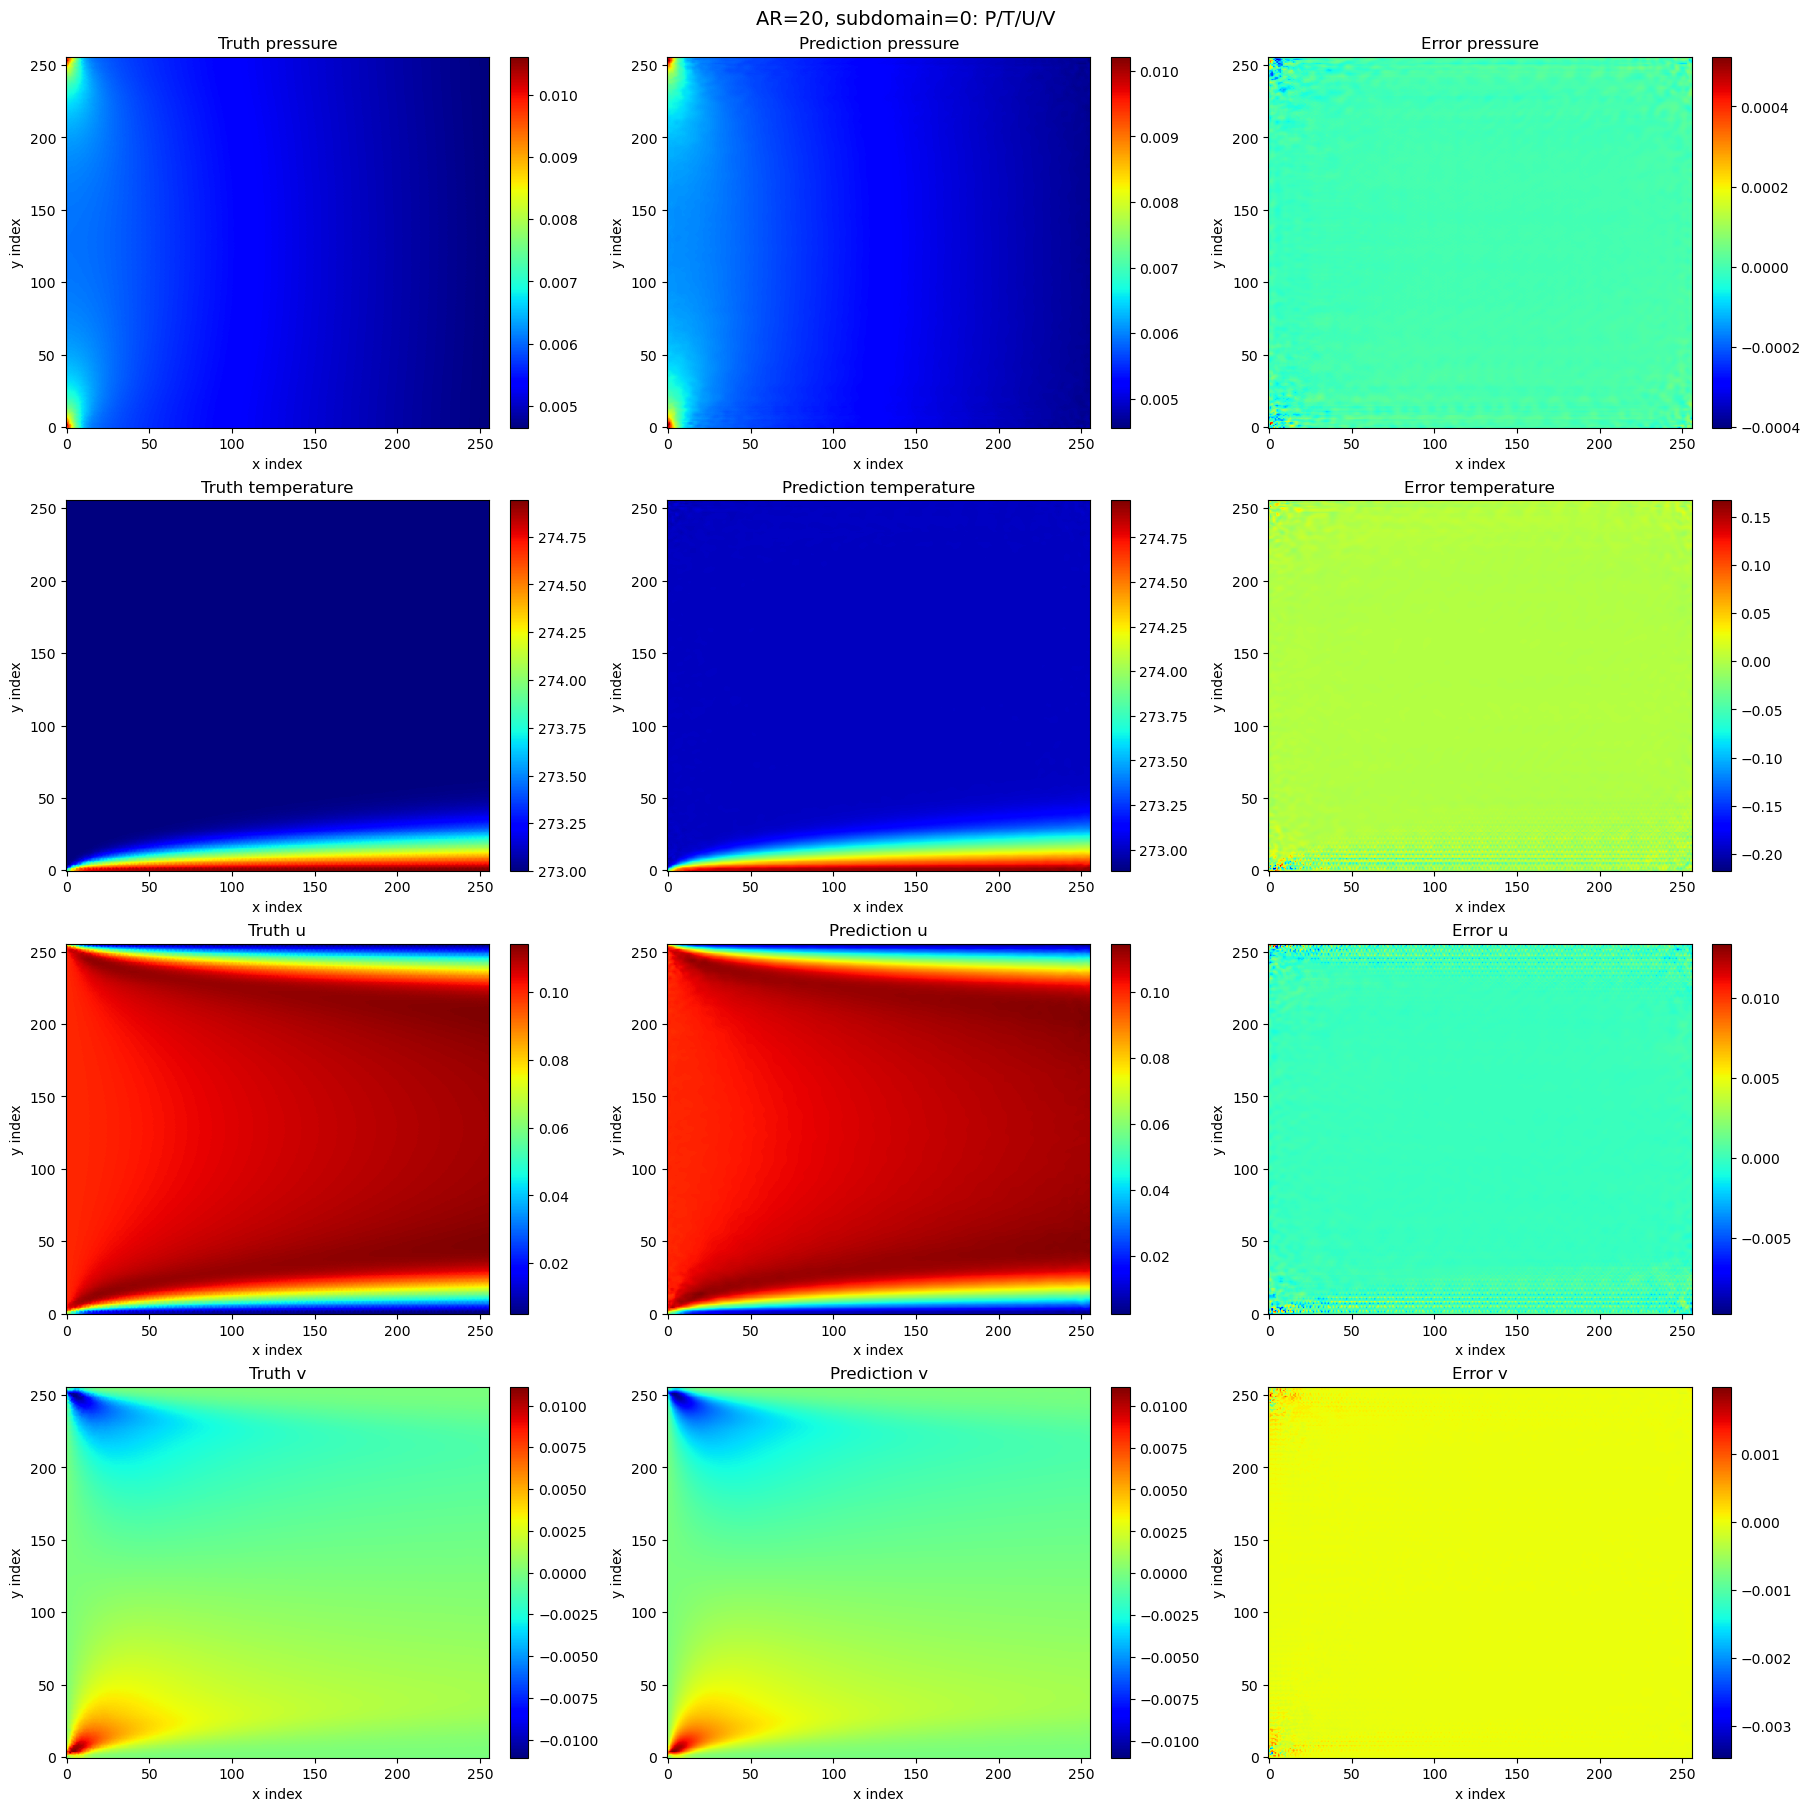

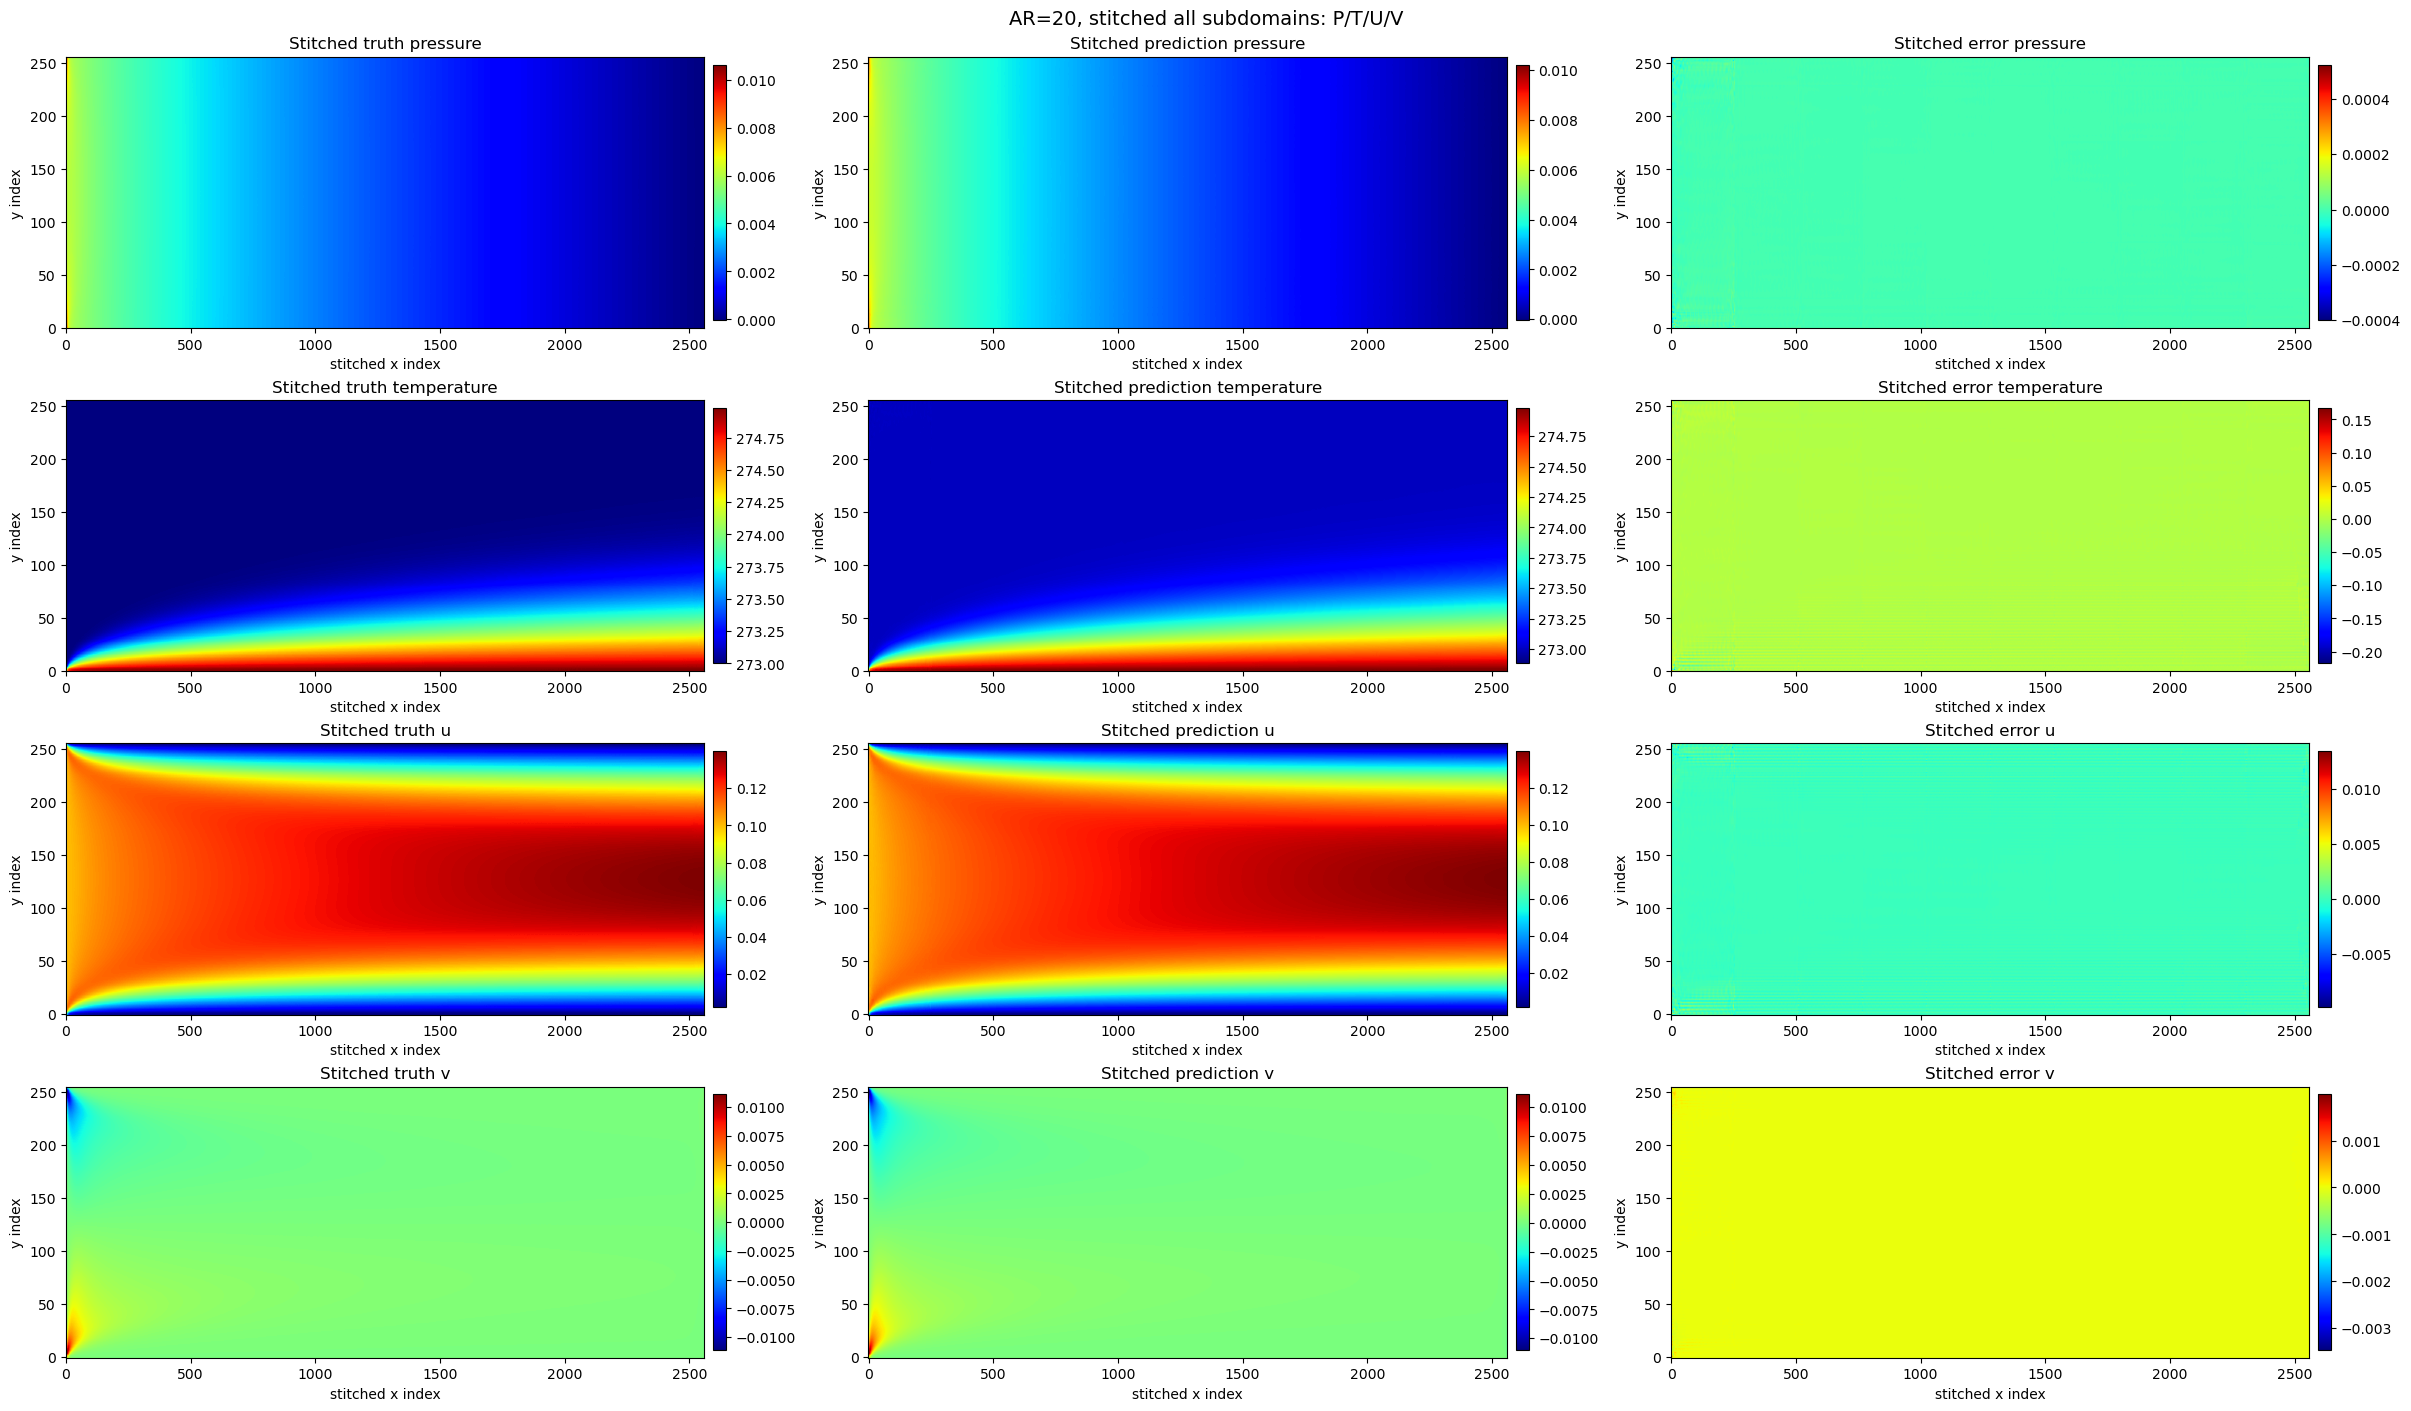

In [42]:
sample_id = 0
sample_ar = int(ars[valid_idx[sample_id]])
sample_subdomain = int(subdomain_ids[valid_idx[sample_id]])

# Collect all validation subdomains for this AR geometry,
# sort by subdomain id, and stitch along x for a long-domain plot.
ar_mask = ars[valid_idx] == sample_ar
ar_local_idx = np.flatnonzero(ar_mask)
ar_subdomain_ids = subdomain_ids[valid_idx[ar_local_idx]]
sort_order = np.argsort(ar_subdomain_ids)
ar_local_idx = ar_local_idx[sort_order]
ar_subdomain_ids = ar_subdomain_ids[sort_order]

print("Validation sample:")
print("AR:", sample_ar)
print("Subdomain:", sample_subdomain)
print("Stitched subdomains:", ar_subdomain_ids.tolist())

# Figure 1: single subdomain, all fields (vertical layout)
fig1, axes1 = plt.subplots(len(output_channel_names), 3, figsize=(18, 18), constrained_layout=True)

for fi, fname in enumerate(output_channel_names):
    truth_field = truth_valid[sample_id, :, :, fi]
    pred_field = pred_valid[sample_id, :, :, fi]
    err_field = pred_field - truth_field

    im = axes1[fi, 0].imshow(truth_field.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 0].set_title(f"Truth {fname}")
    axes1[fi, 0].set_xlabel("x index")
    axes1[fi, 0].set_ylabel("y index")
    plt.colorbar(im, ax=axes1[fi, 0], fraction=0.046, pad=0.04)

    im = axes1[fi, 1].imshow(pred_field.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 1].set_title(f"Prediction {fname}")
    axes1[fi, 1].set_xlabel("x index")
    axes1[fi, 1].set_ylabel("y index")
    plt.colorbar(im, ax=axes1[fi, 1], fraction=0.046, pad=0.04)

    im = axes1[fi, 2].imshow(err_field.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 2].set_title(f"Error {fname}")
    axes1[fi, 2].set_xlabel("x index")
    axes1[fi, 2].set_ylabel("y index")
    plt.colorbar(im, ax=axes1[fi, 2], fraction=0.046, pad=0.04)

fig1.suptitle(f"AR={sample_ar}, subdomain={sample_subdomain}: P/T/U/V", fontsize=14)
plt.show()

# Figure 2: stitched all subdomains, all fields (vertical layout, wider)
fig2, axes2 = plt.subplots(len(output_channel_names), 3, figsize=(24, 14), constrained_layout=True)

for fi, fname in enumerate(output_channel_names):
    truth_stitched = np.concatenate([truth_valid[i, :, :, fi] for i in ar_local_idx], axis=0)
    pred_stitched = np.concatenate([pred_valid[i, :, :, fi] for i in ar_local_idx], axis=0)
    err_stitched = pred_stitched - truth_stitched

    im = axes2[fi, 0].imshow(truth_stitched.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 0].set_title(f"Stitched truth {fname}")
    axes2[fi, 0].set_xlabel("stitched x index")
    axes2[fi, 0].set_ylabel("y index")
    plt.colorbar(im, ax=axes2[fi, 0], fraction=0.02, pad=0.01)

    im = axes2[fi, 1].imshow(pred_stitched.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 1].set_title(f"Stitched prediction {fname}")
    axes2[fi, 1].set_xlabel("stitched x index")
    axes2[fi, 1].set_ylabel("y index")
    plt.colorbar(im, ax=axes2[fi, 1], fraction=0.02, pad=0.01)

    im = axes2[fi, 2].imshow(err_stitched.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 2].set_title(f"Stitched error {fname}")
    axes2[fi, 2].set_xlabel("stitched x index")
    axes2[fi, 2].set_ylabel("y index")
    plt.colorbar(im, ax=axes2[fi, 2], fraction=0.02, pad=0.01)

fig2.suptitle(f"AR={sample_ar}, stitched all subdomains: P/T/U/V", fontsize=14)
plt.show()


In [ ]:
# --- AR=50 test set with 20 subdomains ---
AR_TEST = 50
TEST_SUBDOMAINS = 10
TEST_BATCH_SIZE = 16

case_files_test = {
    AR_TEST: {
        "mesh": ROOT_DIR / f"rect_ar{AR_TEST:02d}_1e-1mps_2c/rect_ar{AR_TEST:02d}.msh.h5",
        "dat": ROOT_DIR / f"rect_ar{AR_TEST:02d}_1e-1mps_2c/case2d.dat.h5",
    }
}

for name, p in case_files_test[AR_TEST].items():
    print(f"AR={AR_TEST} {name} exists:", p.exists(), p)

ar50_dataset = build_fluent_fno_dataset(
    case_files=case_files_test,
    ar_min=AR_TEST,
    ar_max=AR_TEST,
    nx=nx,
    ny=ny,
    n_subdomains=TEST_SUBDOMAINS,
    input_mode=INPUT_MODE,
    layout="NHWC",
)

X_test_np = ar50_dataset["inputs"].astype(np.float32)
Y_test_np = ar50_dataset["outputs"].astype(np.float32)

ar_test = np.asarray(ar50_dataset["aspect_ratio"]).astype(int)
subdomain_test = np.asarray(ar50_dataset["subdomain_id"]).astype(int)

print("X_test_np:", X_test_np.shape)
print("Y_test_np:", Y_test_np.shape)
print("ARs in test set:", sorted(set(ar_test.tolist())))
print("Subdomain IDs in test set:", sorted(set(subdomain_test.tolist())))

X_test_raw = torch.from_numpy(X_test_np).float()
Y_test_raw = torch.from_numpy(Y_test_np).float()

pred_test_chunks = []
truth_test_chunks = []

with torch.no_grad():
    for i0 in range(0, X_test_raw.shape[0], TEST_BATCH_SIZE):
        xb = X_test_raw[i0:i0 + TEST_BATCH_SIZE].to(DEVICE)
        yb = Y_test_raw[i0:i0 + TEST_BATCH_SIZE].to(DEVICE)

        xb_norm = x_normalizer.encode(xb)
        pred_norm = best_model(xb_norm)

        pred_phys = y_normalizer.decode(pred_norm)

        pred_test_chunks.append(pred_phys.detach().cpu().numpy())
        truth_test_chunks.append(yb.detach().cpu().numpy())

pred_test = np.concatenate(pred_test_chunks, axis=0)
truth_test = np.concatenate(truth_test_chunks, axis=0)

# Relative L2 metrics
num = np.linalg.norm((pred_test - truth_test).reshape(pred_test.shape[0], -1), axis=1)
den = np.linalg.norm(truth_test.reshape(truth_test.shape[0], -1), axis=1) + 1.0e-12
sample_rel_l2 = num / den
overall_rel_l2 = float(np.mean(sample_rel_l2))

per_field_rel_l2 = {}
for fi, fname in enumerate(output_channel_names):
    num_f = np.linalg.norm((pred_test[..., fi] - truth_test[..., fi]).reshape(pred_test.shape[0], -1), axis=1)
    den_f = np.linalg.norm(truth_test[..., fi].reshape(truth_test.shape[0], -1), axis=1) + 1.0e-12
    per_field_rel_l2[fname] = float(np.mean(num_f / den_f))

print(f"AR={AR_TEST} overall relative L2: {overall_rel_l2:.6e}")
for fname in output_channel_names:
    print(f"AR={AR_TEST} {fname} relative L2: {per_field_rel_l2[fname]:.6e}")

pred_path_ar50 = f"results/test_predictions_ar{AR_TEST}_sub{TEST_SUBDOMAINS}_{INPUT_MODE}_{EPOCHS}e.npz"
np.savez(
    pred_path_ar50,
    pred=pred_test,
    truth=truth_test,
    ar=ar_test,
    subdomain_id=subdomain_test,
    output_channel_names=np.array(output_channel_names, dtype=object),
    sample_rel_l2=sample_rel_l2,
)
print("Saved:", pred_path_ar50)

AR=50 mesh exists: True /home/hantianl/Documents/PIDIF/runs_2d/rect_ar/rect_ar50_1e-1mps_2c/rect_ar50.msh.h5
AR=50 dat exists: True /home/hantianl/Documents/PIDIF/runs_2d/rect_ar/rect_ar50_1e-1mps_2c/case2d.dat.h5
Processing AR=50
X_test_np: (10, 256, 256, 16)
Y_test_np: (10, 256, 256, 4)
ARs in test set: [50]
Subdomain IDs in test set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
AR=50 overall relative L2: 9.653191e-05
AR=50 pressure relative L2: 1.733114e-02
AR=50 temperature relative L2: 9.639174e-05
AR=50 u relative L2: 1.303891e-02
AR=50 v relative L2: 5.159038e-01
Saved: results/test_predictions_ar50_sub10_local_full16_broadcast.npz


In [44]:
X_test_np.shape

(10, 256, 256, 16)

Plotting AR=50 sample index: 0 subdomain: 0
Stitched subdomains: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


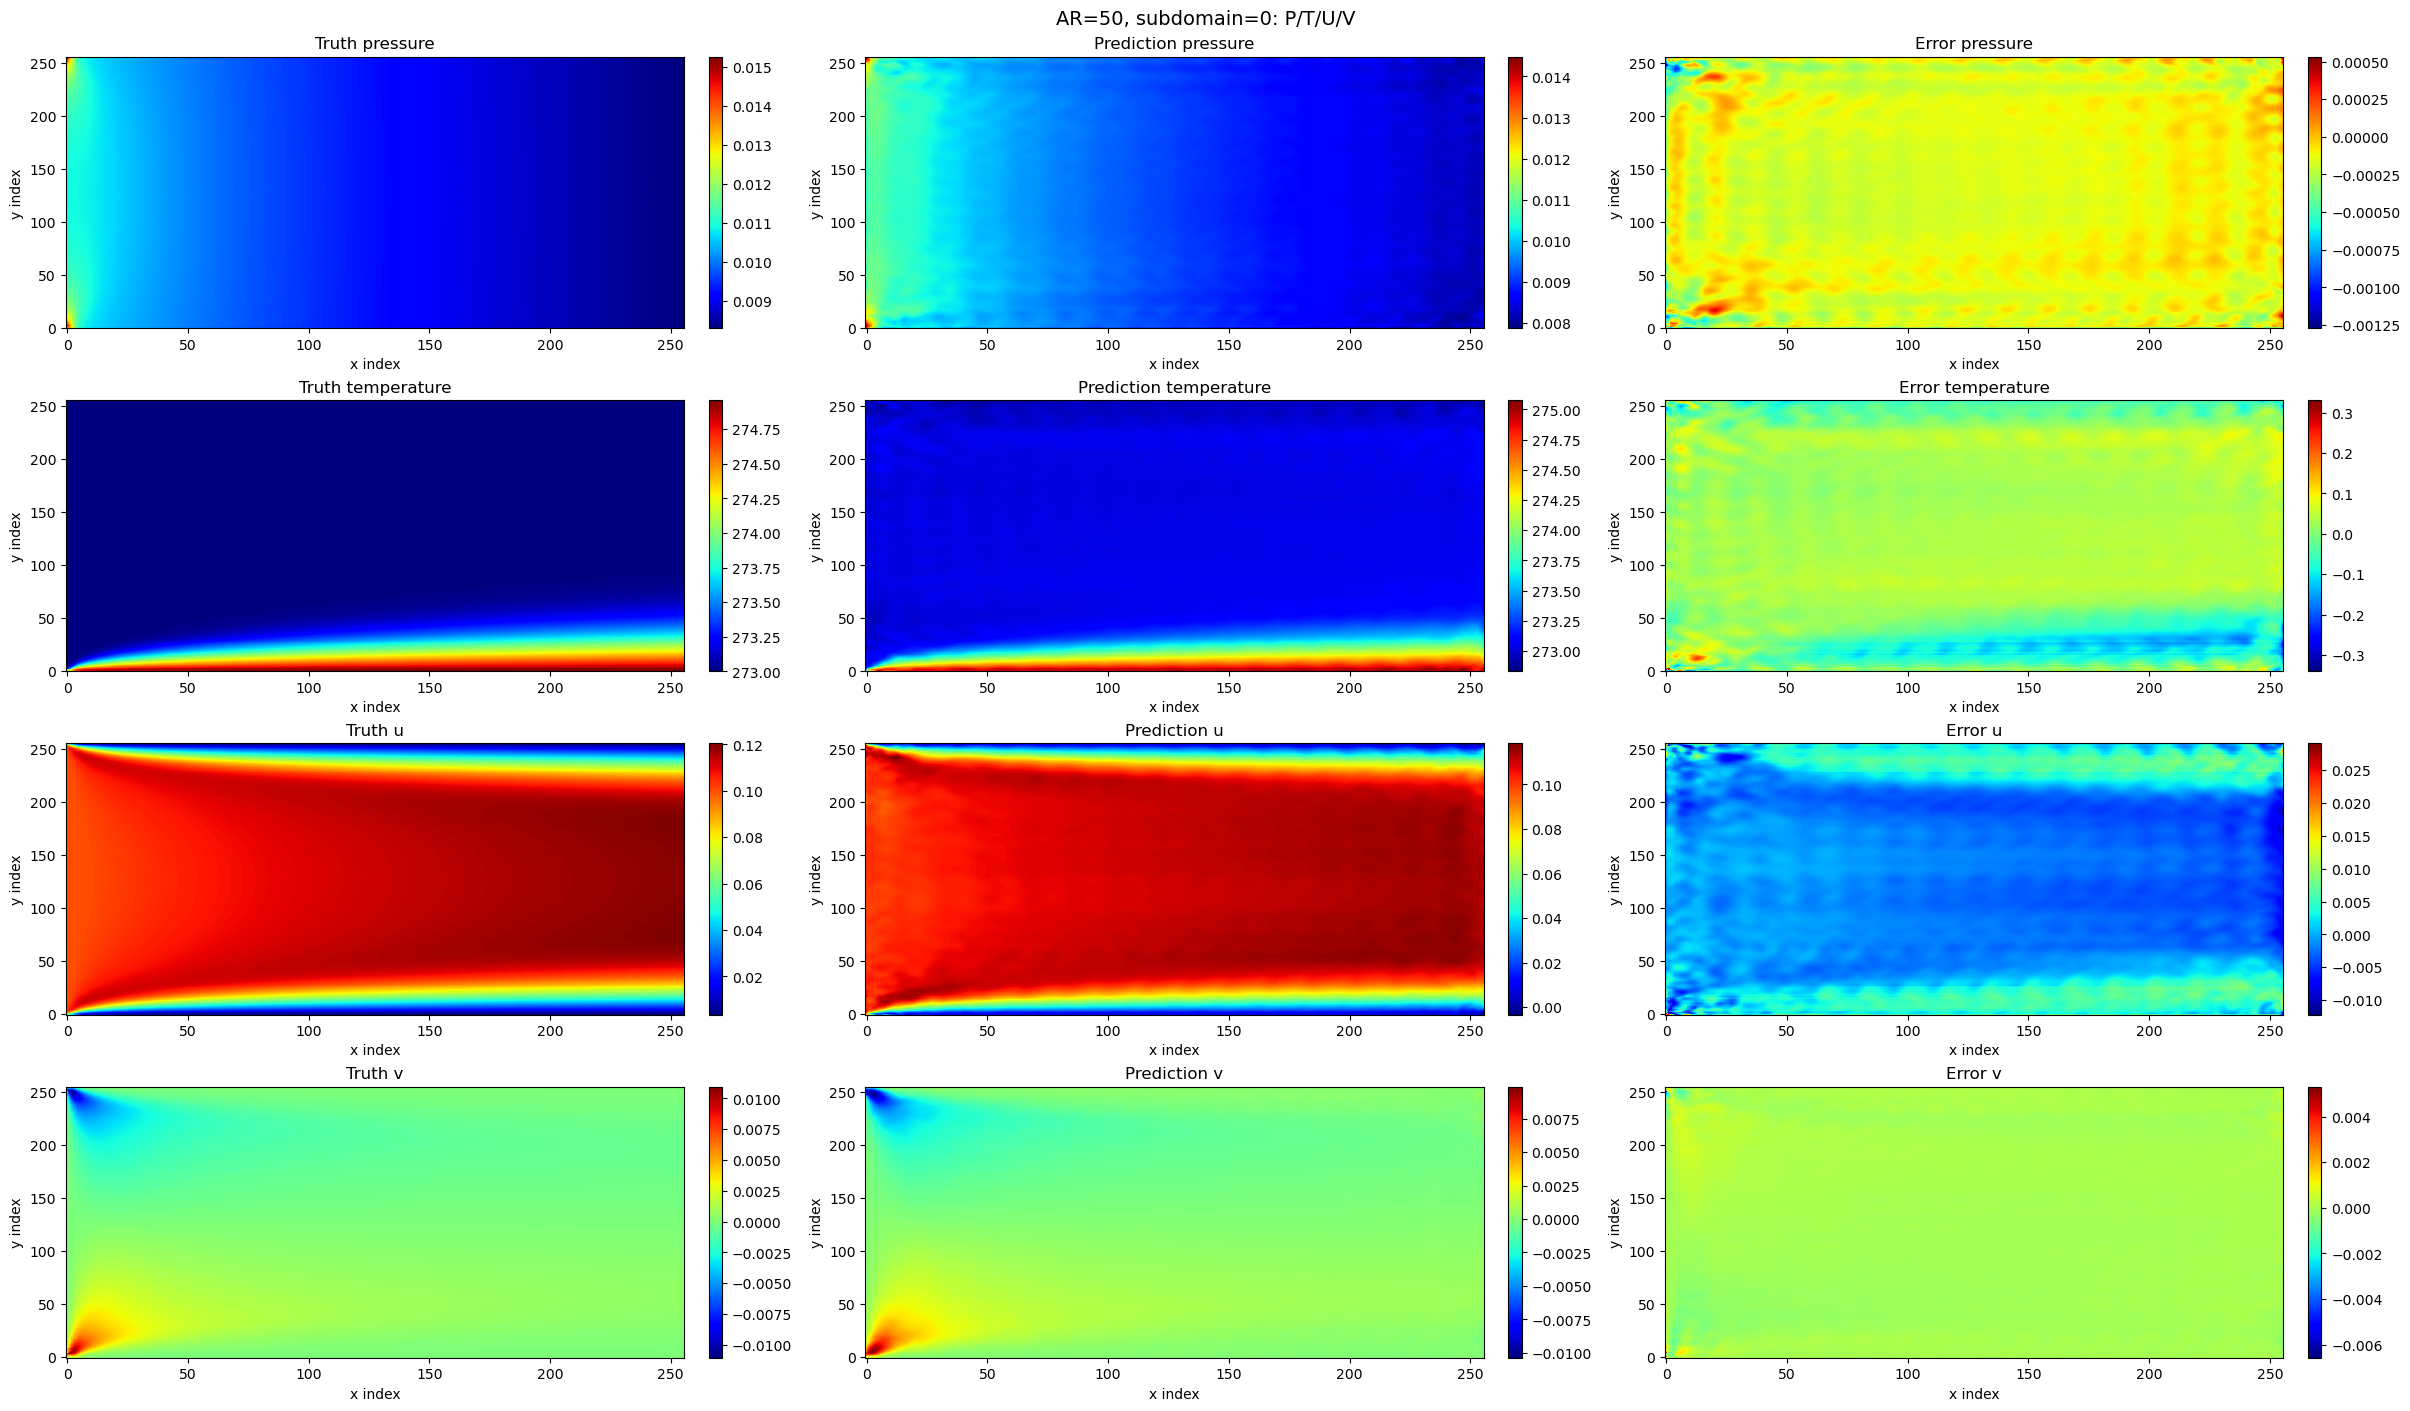

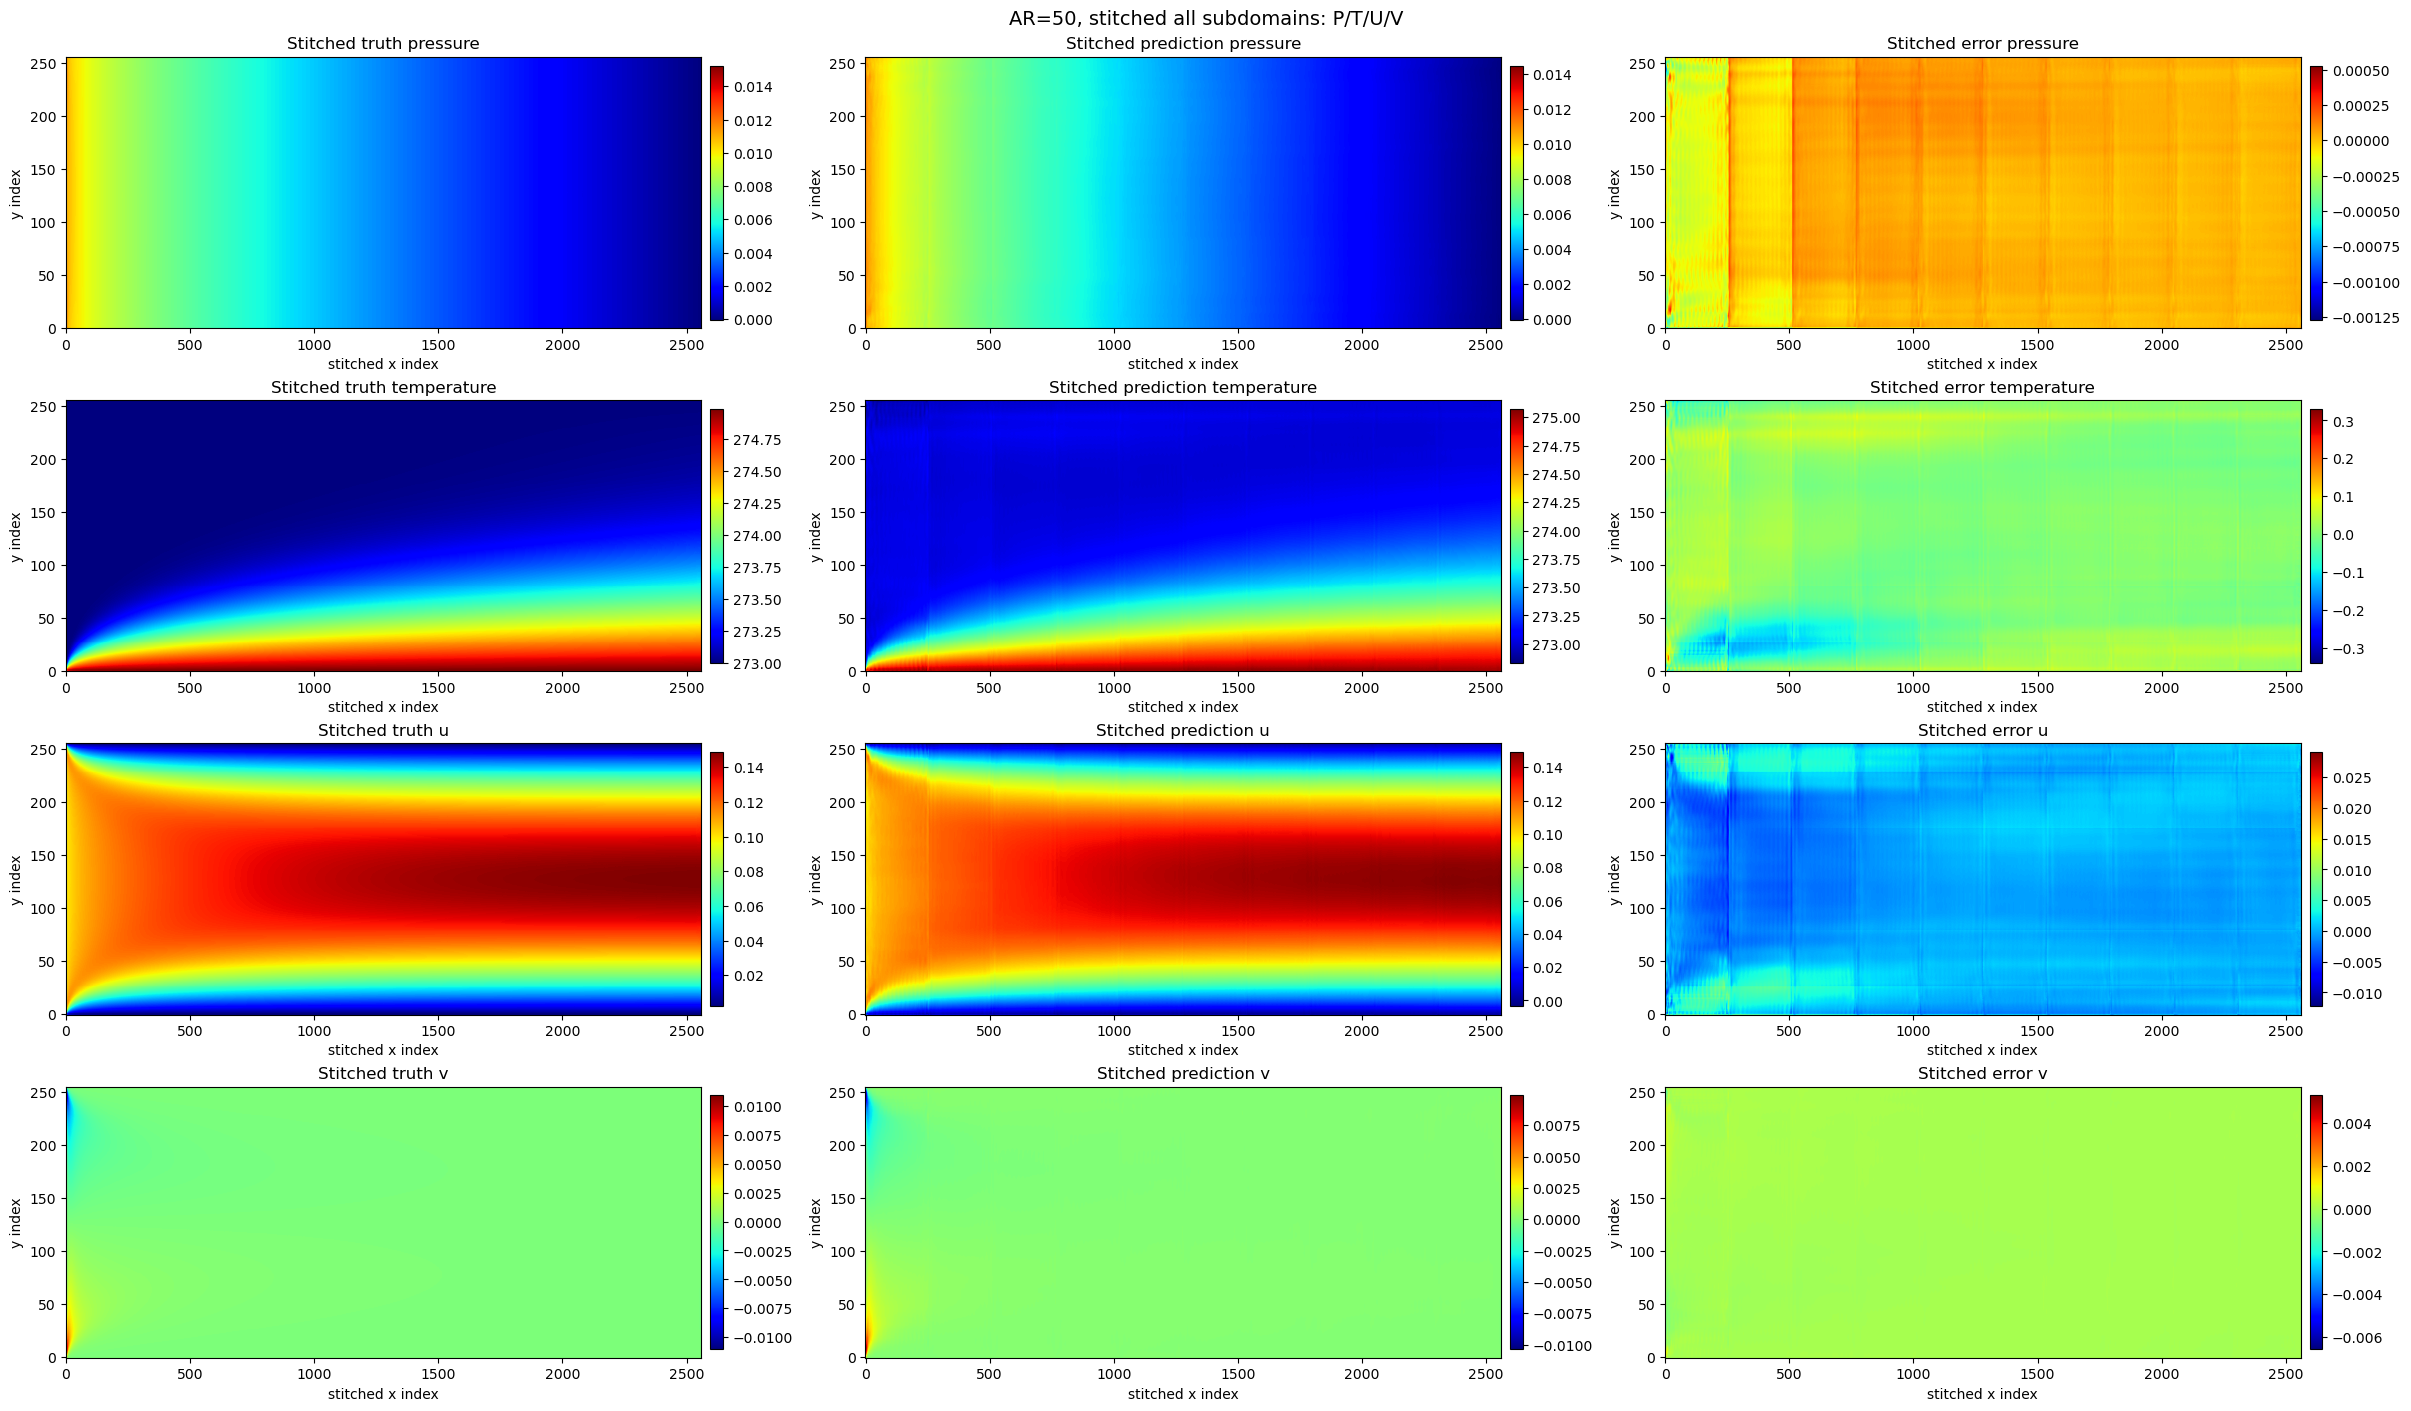

In [45]:
# --- Plot P/T/U/V on one AR=50 subdomain ---
subdomain_to_plot = 0
sample_candidates = np.where(subdomain_test == subdomain_to_plot)[0]
if len(sample_candidates) == 0:
    raise ValueError(f"Subdomain {subdomain_to_plot} not found in AR={AR_TEST} test set")

sample_idx = int(sample_candidates[0])
print("Plotting AR=50 sample index:", sample_idx, "subdomain:", subdomain_test[sample_idx])

# Stitched full geometry (sorted by subdomain id)
sort_idx = np.argsort(subdomain_test)
subdomain_sorted = subdomain_test[sort_idx]
pred_stitched = np.concatenate([pred_test[i] for i in sort_idx], axis=0)
truth_stitched = np.concatenate([truth_test[i] for i in sort_idx], axis=0)
err_stitched = pred_stitched - truth_stitched
print("Stitched subdomains:", subdomain_sorted.tolist())

# Figure 1: single subdomain, vertical layout (rows=fields, cols=truth/pred/error)
fig1, axes1 = plt.subplots(len(output_channel_names), 3, figsize=(24, 14), constrained_layout=True)

for fi, fname in enumerate(output_channel_names):
    truth_f = truth_test[sample_idx, :, :, fi]
    pred_f = pred_test[sample_idx, :, :, fi]
    err_f = pred_f - truth_f

    im0 = axes1[fi, 0].imshow(truth_f.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 0].set_title(f"Truth {fname}")
    axes1[fi, 0].set_xlabel("x index")
    axes1[fi, 0].set_ylabel("y index")
    plt.colorbar(im0, ax=axes1[fi, 0], fraction=0.046, pad=0.04)

    im1 = axes1[fi, 1].imshow(pred_f.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 1].set_title(f"Prediction {fname}")
    axes1[fi, 1].set_xlabel("x index")
    axes1[fi, 1].set_ylabel("y index")
    plt.colorbar(im1, ax=axes1[fi, 1], fraction=0.046, pad=0.04)

    im2 = axes1[fi, 2].imshow(err_f.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 2].set_title(f"Error {fname}")
    axes1[fi, 2].set_xlabel("x index")
    axes1[fi, 2].set_ylabel("y index")
    plt.colorbar(im2, ax=axes1[fi, 2], fraction=0.046, pad=0.04)

fig1.suptitle(f"AR={AR_TEST}, subdomain={subdomain_to_plot}: P/T/U/V", fontsize=14)
plt.show()

# Figure 2: stitched full geometry, vertical layout, wider aspect
fig2, axes2 = plt.subplots(len(output_channel_names), 3, figsize=(24, 14), constrained_layout=True)

for fi, fname in enumerate(output_channel_names):
    truth_f = truth_stitched[:, :, fi]
    pred_f = pred_stitched[:, :, fi]
    err_f = err_stitched[:, :, fi]

    im0 = axes2[fi, 0].imshow(truth_f.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 0].set_title(f"Stitched truth {fname}")
    axes2[fi, 0].set_xlabel("stitched x index")
    axes2[fi, 0].set_ylabel("y index")
    plt.colorbar(im0, ax=axes2[fi, 0], fraction=0.02, pad=0.01)

    im1 = axes2[fi, 1].imshow(pred_f.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 1].set_title(f"Stitched prediction {fname}")
    axes2[fi, 1].set_xlabel("stitched x index")
    axes2[fi, 1].set_ylabel("y index")
    plt.colorbar(im1, ax=axes2[fi, 1], fraction=0.02, pad=0.01)

    im2 = axes2[fi, 2].imshow(err_f.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 2].set_title(f"Stitched error {fname}")
    axes2[fi, 2].set_xlabel("stitched x index")
    axes2[fi, 2].set_ylabel("y index")
    plt.colorbar(im2, ax=axes2[fi, 2], fraction=0.02, pad=0.01)

fig2.suptitle(f"AR={AR_TEST}, stitched all subdomains: P/T/U/V", fontsize=14)
plt.show()